# O1 — MPC mastery (concept + implementation)
* Understand MPC mathematically, practically, and statistically.
* Know exactly how preprocessing choices (filter, Hilbert, phase unwrap, edge effects) change results.
* Establish “MPC is high” ≠ “true coupling” unless confounds are ruled out.

These are the “characteristics” backed up with controlled experiments:

### C. Frequency mismatch (“wavelength / faster frequency”)

If signals have different dominant frequencies, relative phase drifts → MPC drops unless windows are extremely short or there’s true locking.

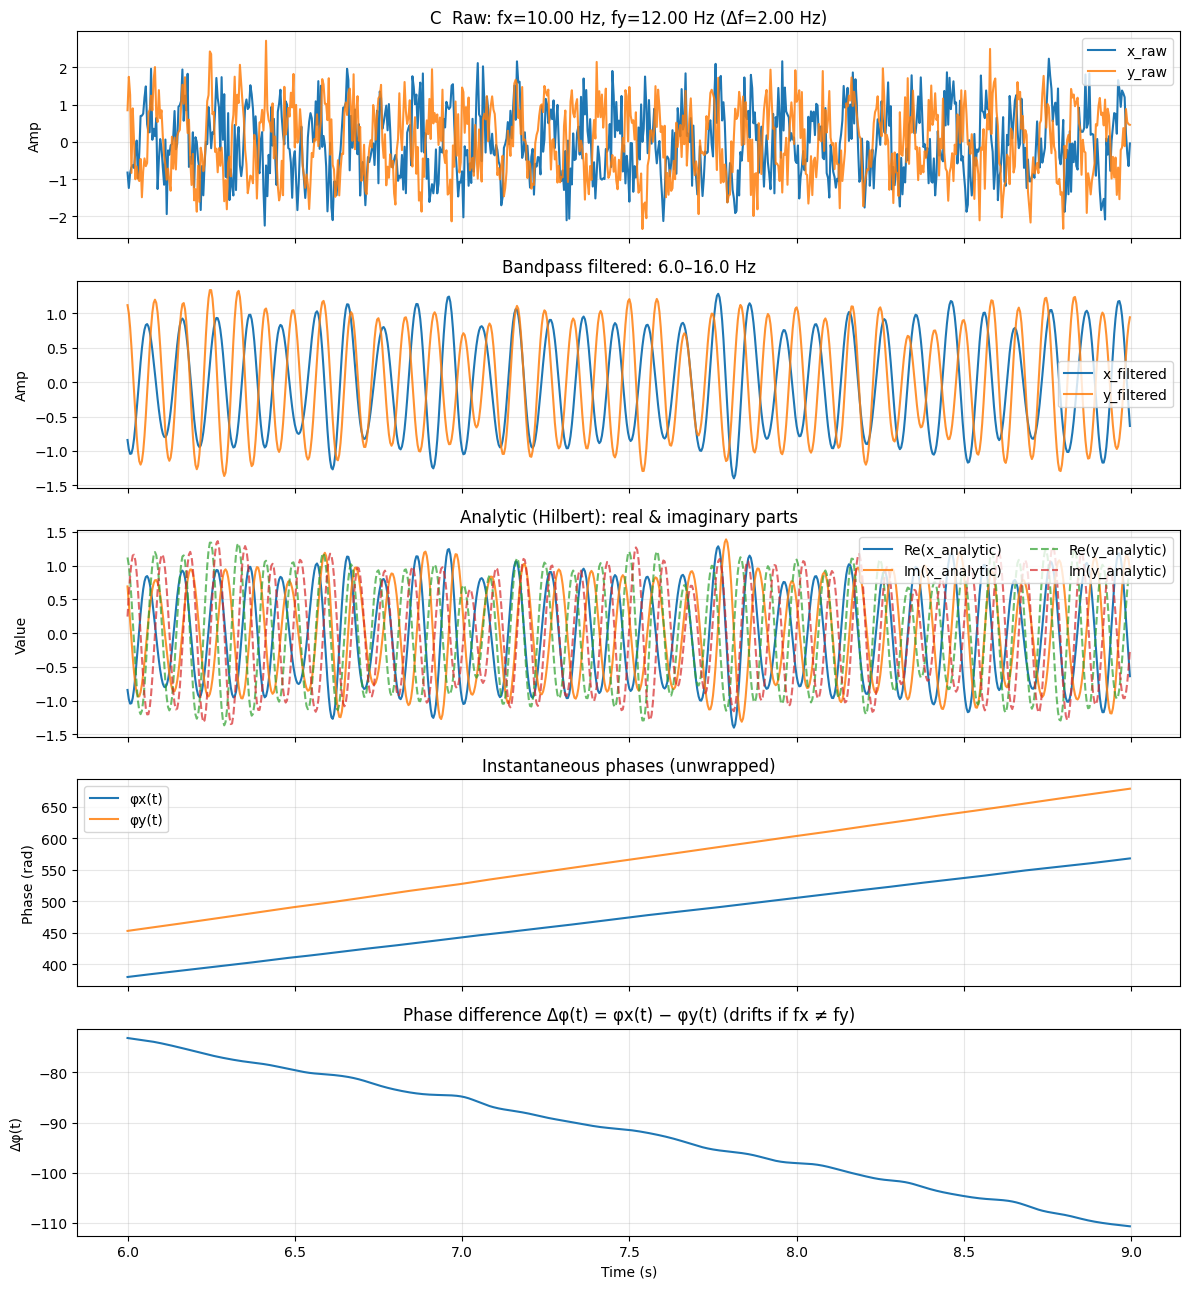

Computing pooled MPC samples across pairs/windows...


Δf loop:   0%|          | 0/6 [00:00<?, ?it/s]

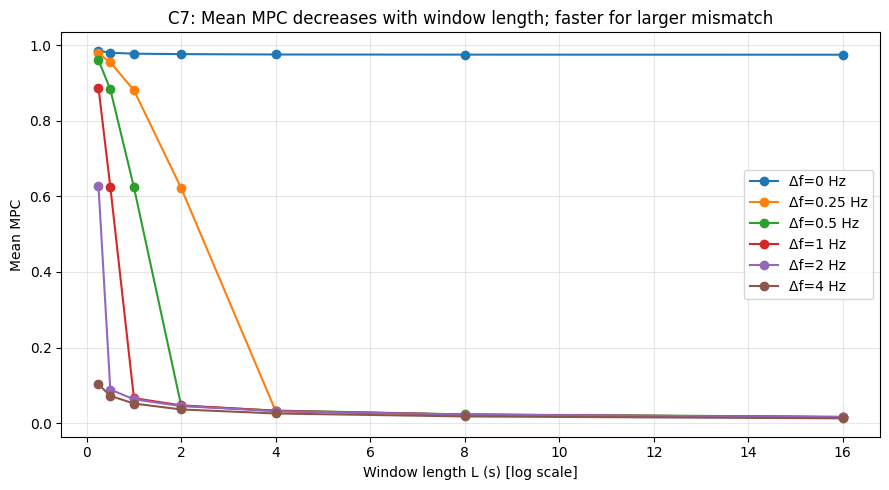

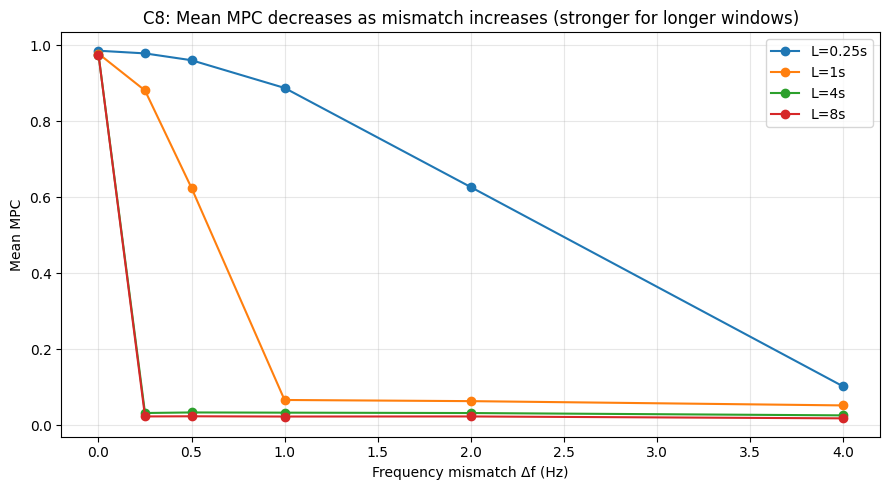


Mean MPC summary table:
Rows = Δf (Hz), Columns = L (s)
Δf\L |   0.25     0.5       1       2       4       8      16
-------------------------------------------------------------
   0 |   0.985   0.980   0.977   0.976   0.975   0.975   0.974
0.25 |   0.978   0.954   0.880   0.622   0.032   0.023   0.016
 0.5 |   0.960   0.883   0.624   0.046   0.033   0.023   0.017
   1 |   0.887   0.625   0.066   0.047   0.033   0.023   0.016
   2 |   0.626   0.089   0.063   0.045   0.032   0.023   0.016
   4 |   0.102   0.073   0.052   0.036   0.026   0.018   0.013


In [1]:
# ============================================================
# O1.C — Frequency mismatch
#
# What this section shows:
# - If two signals have different dominant frequencies (Δf != 0),
#   their relative phase Δφ(t) drifts.
# - As window length increases, that drift causes more cancellation
#   in exp(iΔφ) and MPC decreases.
# - Larger mismatch -> faster drift -> MPC drops faster.
#
# Design choices (kept simple):
# - Signals: independent noisy sinusoids with frequencies fx=f0 and fy=f0+Δf
# - Phase pipeline: bandpass (single band that contains ALL frequencies) + Hilbert + unwrap
# - Robustness: average over many signal pairs and many random windows
# - Visuals: pipeline demo + two clean plots (means only)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

# Optional progress bar
try:
    from tqdm.auto import tqdm
    _tqdm = tqdm
except Exception:
    def _tqdm(x, **kwargs):
        return x

rng = np.random.default_rng(0)

# ------------------- settings -------------------
fs = 256
T = 30.0
n = int(T * fs)
t = np.arange(n) / fs

f0 = 10.0
mismatches = np.array([0.0, 0.25, 0.5, 1.0, 2.0, 4.0])  # Δf = fy - fx

# IMPORTANT: band must include f0 and f0+max(Δf)
# Here f0=10, max Δf=4 => up to 14 Hz.
band = (6.0, 16.0)
order = 4

window_lengths_s = np.array([0.25, 0.5, 1, 2, 4, 8, 16])

# Monte Carlo robustness controls
n_pairs = 120
n_windows_per_pair = 12

noise_std = 0.6
amp = 1.0

edge_trim_s = 1.0
edge_trim = int(edge_trim_s * fs)

# ------------------- helpers -------------------
def bandpass_filter(x, fs, band, order=4):
    sos = sg.butter(order, band, btype="bandpass", fs=fs, output="sos")
    return sg.sosfiltfilt(sos, x)

def hilbert_phase(x_filt):
    xa = sg.hilbert(x_filt)
    return xa, np.unwrap(np.angle(xa))

def mpc_from_phases(phi_x, phi_y):
    # MPC exactly as in paper: |(1/N) sum exp(i (phi_x - phi_y))|
    dphi = phi_x - phi_y
    return np.abs(np.mean(np.exp(1j * dphi)))

def make_pair(fx, fy, amp=1.0, noise_std=0.6):
    phx0 = rng.uniform(0, 2*np.pi)
    phy0 = rng.uniform(0, 2*np.pi)
    x = amp*np.sin(2*np.pi*fx*t + phx0) + noise_std*rng.standard_normal(n)
    y = amp*np.sin(2*np.pi*fy*t + phy0) + noise_std*rng.standard_normal(n)
    return x, y

def sample_mpc_values(phi_x, phi_y, fs, L_s, n_windows):
    W = int(L_s * fs)
    max_start = len(phi_x) - W
    starts = rng.integers(0, max_start, size=n_windows)
    vals = np.empty(n_windows, dtype=float)
    for k, s in enumerate(starts):
        vals[k] = mpc_from_phases(phi_x[s:s+W], phi_y[s:s+W])
    return vals

# ============================================================
# 1) PIPELINE DEMO (one example) — shows drift in Δφ(t)
# ============================================================
df_demo = 2.0
fx_demo, fy_demo = f0, f0 + df_demo

x_raw, y_raw = make_pair(fx_demo, fy_demo, amp=amp, noise_std=noise_std)
x_f = bandpass_filter(x_raw, fs, band, order)
y_f = bandpass_filter(y_raw, fs, band, order)
xa, phx = hilbert_phase(x_f)
ya, phy = hilbert_phase(y_f)

# trim edges for clean visuals
sl = slice(edge_trim, -edge_trim)
tt = t[sl]
x_raw, y_raw = x_raw[sl], y_raw[sl]
x_f, y_f = x_f[sl], y_f[sl]
xa, ya = xa[sl], ya[sl]
phx, phy = phx[sl], phy[sl]
dphi = phx - phy

# zoom segment
zoom_start_s = 5.0
zoom_len_s = 3.0
z0 = int(zoom_start_s * fs)
z1 = z0 + int(zoom_len_s * fs)

fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
axes[0].plot(tt[z0:z1], x_raw[z0:z1], label="x_raw")
axes[0].plot(tt[z0:z1], y_raw[z0:z1], label="y_raw", alpha=0.85)
axes[0].set_title(f"C  Raw: fx={fx_demo:.2f} Hz, fy={fy_demo:.2f} Hz (Δf={df_demo:.2f} Hz)")
axes[0].set_ylabel("Amp")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(tt[z0:z1], x_f[z0:z1], label="x_filtered")
axes[1].plot(tt[z0:z1], y_f[z0:z1], label="y_filtered", alpha=0.85)
axes[1].set_title(f"Bandpass filtered: {band[0]:.1f}–{band[1]:.1f} Hz")
axes[1].set_ylabel("Amp")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(tt[z0:z1], np.real(xa[z0:z1]), label="Re(x_analytic)")
axes[2].plot(tt[z0:z1], np.imag(xa[z0:z1]), label="Im(x_analytic)", alpha=0.85)
axes[2].plot(tt[z0:z1], np.real(ya[z0:z1]), label="Re(y_analytic)", linestyle="--", alpha=0.7)
axes[2].plot(tt[z0:z1], np.imag(ya[z0:z1]), label="Im(y_analytic)", linestyle="--", alpha=0.7)
axes[2].set_title("Analytic (Hilbert): real & imaginary parts")
axes[2].set_ylabel("Value")
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncols=2, loc="upper right")

axes[3].plot(tt[z0:z1], phx[z0:z1], label="φx(t)")
axes[3].plot(tt[z0:z1], phy[z0:z1], label="φy(t)", alpha=0.85)
axes[3].set_title("Instantaneous phases (unwrapped)")
axes[3].set_ylabel("Phase (rad)")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[4].plot(tt[z0:z1], dphi[z0:z1])
axes[4].set_title("Phase difference Δφ(t) = φx(t) − φy(t) (drifts if fx ≠ fy)")
axes[4].set_ylabel("Δφ(t)")
axes[4].set_xlabel("Time (s)")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 2) MAIN MONTE CARLO: Build pooled MPC samples per (Δf, L)
# ============================================================
dist = {}  # dist[(df, Ls)] = pooled MPC samples

print("Computing pooled MPC samples across pairs/windows...")
for df in _tqdm(mismatches, desc="Δf loop"):
    fx, fy = f0, f0 + df

    pooled = {Ls: [] for Ls in window_lengths_s}

    for _ in range(n_pairs):
        x, y = make_pair(fx, fy, amp=amp, noise_std=noise_std)

        x_f = bandpass_filter(x, fs, band, order)
        y_f = bandpass_filter(y, fs, band, order)

        _, phx = hilbert_phase(x_f)
        _, phy = hilbert_phase(y_f)

        phx = phx[edge_trim:-edge_trim]
        phy = phy[edge_trim:-edge_trim]

        for Ls in window_lengths_s:
            vals = sample_mpc_values(phx, phy, fs, Ls, n_windows_per_pair)
            pooled[Ls].append(vals)

    for Ls in window_lengths_s:
        dist[(df, Ls)] = np.concatenate(pooled[Ls])

# ============================================================
# 3) C7 — Mean MPC vs window length for each mismatch (MEANS ONLY)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

for df in mismatches:
    means = []
    for Ls in window_lengths_s:
        means.append(dist[(df, Ls)].mean())
    means = np.array(means)
    ax.plot(window_lengths_s, means, marker="o", label=f"Δf={df:g} Hz")

#ax.set_xscale("log")
ax.set_xlabel("Window length L (s) [log scale]")
ax.set_ylabel("Mean MPC")
ax.set_title("C7: Mean MPC decreases with window length; faster for larger mismatch")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 4) C8 — Mean MPC vs mismatch for selected window lengths (MEANS ONLY)
# ============================================================
Ls_show = [0.25, 1.0, 4.0, 8.0]

fig, ax = plt.subplots(figsize=(9, 5))

for Ls in Ls_show:
    means = []
    for df in mismatches:
        means.append(dist[(df, Ls)].mean())
    means = np.array(means)
    ax.plot(mismatches, means, marker="o", label=f"L={Ls:g}s")

ax.set_xlabel("Frequency mismatch Δf (Hz)")
ax.set_ylabel("Mean MPC")
ax.set_title("C8: Mean MPC decreases as mismatch increases (stronger for longer windows)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 5) Optional: tiny summary table (means only)
# ============================================================
print("\nMean MPC summary table:")
print("Rows = Δf (Hz), Columns = L (s)")
header = "Δf\\L | " + "  ".join([f"{Ls:>6g}" for Ls in window_lengths_s])
print(header)
print("-" * len(header))

for df in mismatches:
    row = [f"{df:>4g} |"]
    for Ls in window_lengths_s:
        row.append(f"{dist[(df, Ls)].mean():6.3f}")
    print("  ".join(row))
